# Rekurencyjne Sieci Neuronowe (RNN)

Rekurencyjne Sieci Neuronowe (Recurrent Neural Networks, **RNN**) są specjalnym rodzajem sztucznych sieci neuronowych zaprojektowanych do przetwarzania **danych sekwencyjnych**, czyli takich, w których **kolejność obserwacji ma znaczenie**.

W przeciwieństwie do klasycznych modeli uczenia maszynowego, które traktują każdą próbkę danych niezależnie, RNN potrafią wykorzystywać informacje z **poprzednich kroków czasowych** podczas przetwarzania aktualnego wejścia.

Najważniejszą cechą RNN jest obecność **wewnętrznego stanu (hidden state)**, który pełni rolę pamięci sieci. Stan ten jest aktualizowany w każdym kroku przetwarzania sekwencji i przechowuje informację o wcześniejszych elementach danych.

Dzięki temu RNN potrafią modelować **zależności czasowe** oraz **kontekst w sekwencjach danych**.

Typowe zastosowania RNN obejmują:

- analizę **szeregów czasowych**
- **przetwarzanie języka naturalnego (NLP)**
- **rozpoznawanie mowy**
- **generowanie tekstu**
- analizę **sygnałów audio**

---

# 2. Różnice między RNN a sieciami Feed-Forward

## Feed-Forward Neural Network (FFNN)

Klasyczne sieci neuronowe typu **Feed-Forward** są najprostszą architekturą sieci neuronowych.

- Informacja przepływa **w jednym kierunku** — od warstwy wejściowej, przez warstwy ukryte, do warstwy wyjściowej.
- Sieć **nie posiada mechanizmu pamięci**, dlatego każda próbka danych jest analizowana niezależnie.
- Kolejność danych wejściowych **nie wpływa na wynik modelu**.

---

## Recurrent Neural Network (RNN)

Rekurencyjne sieci neuronowe rozszerzają architekturę sieci neuronowych o **połączenia rekurencyjne**, które pozwalają przekazywać informacje pomiędzy kolejnymi krokami przetwarzania sekwencji.

Charakterystyka:

- Komórki sieci posiadają **stan ukryty (hidden state)** przechowujący informację o wcześniejszych elementach sekwencji.
- Dane przetwarzane są **krok po kroku w czasie**.
- Wynik modelu zależy zarówno od **aktualnego wejścia**, jak i od **poprzednich stanów sieci**.
- Architektura umożliwia modelowanie **zależności czasowych** w danych.


---

**Podsumowanie**

- Sieć **Feed-Forward** analizuje dane tak, jak kalkulator — każda obserwacja jest przetwarzana niezależnie.
- Sieć **RNN** działa bardziej jak czytelnik tekstu — rozumie bieżący element sekwencji w kontekście wcześniejszych elementów.

---

`źródło`: Goodfellow, I., Bengio, Y., & Courville, A. (2016). **Deep Learning.** MIT Press. Chapter 10: Sequence Modeling: Recurrent and Recursive Nets.

https://www.deeplearningbook.org
Przykładowa architektura sieci RNN

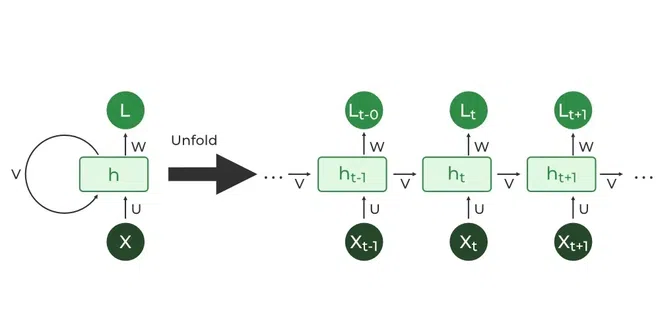

(źródło: https://www.geeksforgeeks.org/introduction-to-recurrent-neural-network/)

### Przykład regresji z użyciem RNN

Przewidywanie miesięcznej ilości pasażerów.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Ładowanie danych
data = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv", parse_dates=["Month"], index_col="Month")
data = data.dropna()
data.head(10)

In [ ]:
# Konwersja do numpy
data = data.values

## Skalowanie zmiennej target
---

**Uwaga**

Zastosowanie **MinMaxScaling** często poprawia stabilność i skuteczność treningu sieci neuronowych. Wynika to z faktu, że wiele algorytmów optymalizacji (np. gradient descent oraz jego warianty) działa efektywniej, gdy dane wejściowe i wyjściowe znajdują się w podobnych zakresach wartości.

Dodatkowo skalowanie może ułatwić interpretację wartości niektórych metryk błędu podczas treningu modelu.

Należy jednak pamiętać, że predykcje modelu są wówczas generowane w **przeskalowanej przestrzeni**. Aby porównać je z danymi w oryginalnej skali, konieczne jest wykonanie operacji odwrotnego skalowania przy użyciu metody `inverse_transform`.

---

### Przykład użycia `MinMaxScaler`

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(<FIT_DATA>)
```

In [ ]:
# Podział na dane treningowe i testowe (ostatnie dane w czasie są brane jako dane testowe)
train_size = int(data.shape[0] * 0.8)
test_size = data.shape[0] - train_size
train, test = data[0:train_size,:], data[train_size:len(data),:]
print(len(train), len(test))

In [ ]:
def create_data(data, seq_length=5, horizon=1):
    X, y = [], []
    for i in range(len(data) - seq_length - horizon):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length + horizon - 1, 0])
    return np.array(X), np.array(y)

In [ ]:
# Tworzenie datasetu
seq_length = 5
X_train, y_train = create_data(train, seq_length)
X_test, y_test = create_data(test, seq_length)

In [ ]:
# Nadanie danym odpowiedniego kształtu do sieci neuronowej
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
X_train_fnn = X_train.reshape(X_train.shape[0], -1)
X_test_fnn = X_test.reshape(X_test.shape[0], -1)

In [ ]:
X_train_fnn.shape

In [ ]:
X_train.shape

In [ ]:
X_test[:2]

In [ ]:
y_test[:10]

In [ ]:
# Definicja Sieci FNN
fnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(seq_length,)),
    Dense(32, activation='relu'),
    Dense(1)
])
fnn_model.compile(optimizer='adam', loss='mae')

In [ ]:
# Przykładowy trening modelu FNN, może być usprawniony
fnn_model.fit(X_train_fnn, y_train, epochs=10, batch_size=8, validation_data=(X_test, y_test))

In [ ]:
# Defninicja Sieci RNN
rnn_model = Sequential([
    SimpleRNN(50, activation='relu', return_sequences=False, input_shape=(seq_length, 1)),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mae')

In [ ]:
# Przykładowy trening modelu RNN, może być usprawniony
rnn_model.fit(X_train, y_train, epochs=10, batch_size=8, validation_data=(X_test, y_test))

In [ ]:
#  Predykcje
y_pred_fnn = fnn_model.predict(X_test_fnn).flatten()
y_pred_rnn = rnn_model.predict(X_test).flatten()

In [ ]:
plt.plot(
    range(seq_length, seq_length + len(y_test)),
    y_test,
    label="True"
)


plt.plot(
    range(seq_length, seq_length + len(y_pred_rnn)),
    y_pred_rnn,
    label="RNN"
)

plt.plot(
    range(seq_length, seq_length + len(y_pred_fnn)),
    y_pred_fnn,
    label="FNN"
)

plt.legend()
plt.show()

## Analiza wpływu kolejności i ostatniego punktu na predykcje FNN i RNN

Bierzemy jedną sekwencję testową i przeprowadzamy trzy eksperymenty:

1. **Odwrócenie kolejności danych (reversed)**  
   Sprawdzamy, czy zmiana kolejności całej sekwencji wpływa na predykcję.
   - FNN przetwarza dane jako wektor → kolejność teoretycznie nie powinna mieć znaczenia.
   - RNN przetwarza dane krok po kroku → kolejność jest kluczowa.

2. **Modyfikacja ostatniego punktu (last value sensitivity)**  
   Zwiększamy ostatnią wartość sekwencji o 100, aby sprawdzić, na ile predykcja zależy od ostatniego elementu.

3. **Losowa permutacja (shuffle)**  
   Sprawdzamy wpływ całkowicie losowej kolejności na predykcje modeli.

**Interpretacja wyników:**  
- Jeśli zmiana kolejności znacząco zmienia predykcję → model rozumie kolejność danych.  
- Jeśli wrażliwość na ostatni punkt jest wysoka → model silnie zależy od końcówki sekwencji.  

In [ ]:
idx = 2
sample = X_test[idx].copy()
true_value = y_test[idx]

print("=== SAMPLE ===")
print("Original:", sample.flatten())
print("True value:", true_value)

# =========================
# Test 1: odwrócenie danych
# =========================
reversed_seq = sample[::-1]

fnn_orig = fnn_model.predict(sample.reshape(1, -1), verbose=0)
fnn_rev  = fnn_model.predict(reversed_seq.reshape(1, -1), verbose=0)

rnn_orig = rnn_model.predict(sample.reshape(1, seq_length, 1), verbose=0)
rnn_rev  = rnn_model.predict(reversed_seq.reshape(1, seq_length, 1), verbose=0)

print("\n=== TEST 1: ODWRÓCENIE DANYCH ===")
print("FNN original :", fnn_orig[0][0])
print("FNN reversed :", fnn_rev[0][0])
print("FNN diff     :", abs(fnn_orig - fnn_rev)[0][0])

print("RNN original :", rnn_orig[0][0])
print("RNN reversed :", rnn_rev[0][0])
print("RNN diff     :", abs(rnn_orig - rnn_rev)[0][0])

# =========================
# TEST 2: WRAŻLIWOŚĆ NA OSTATNI PUNKT DANYCH
# =========================
modified = sample.copy()
modified[-1] += 100  # zmieniamy tylko ostatni punkt

fnn_mod = fnn_model.predict(modified.reshape(1, -1), verbose=0)
rnn_mod = rnn_model.predict(modified.reshape(1, seq_length, 1), verbose=0)

print("\n=== TEST 2: WRAŻLIWOŚĆ NA OSTATNI PUNKT DANYCH")
print("FNN sensitivity:", abs(fnn_orig - fnn_mod)[0][0])
print("RNN sensitivity:", abs(rnn_orig - rnn_mod)[0][0])

# =========================
# 🔥 TEST 3: SHUFFLE
# =========================
shuffled = np.random.permutation(sample)

fnn_shuf = fnn_model.predict(shuffled.reshape(1, -1), verbose=0)
rnn_shuf = rnn_model.predict(shuffled.reshape(1, seq_length, 1), verbose=0)

print("\n=== TEST 3: SHUFFLE ===")
print("FNN shuffled :", fnn_shuf[0][0])
print("RNN shuffled :", rnn_shuf[0][0])

print("\n=== INTERPRETACJA ===")

fnn_diff_rev = abs(fnn_orig - fnn_rev)[0][0]
rnn_diff_rev = abs(rnn_orig - rnn_rev)[0][0]

fnn_last = abs(fnn_orig - fnn_mod)[0][0]
rnn_last = abs(rnn_orig - rnn_mod)[0][0]

print(f"Reverse sensitivity → FNN: {fnn_diff_rev:.2f}, RNN: {rnn_diff_rev:.2f}")
print(f"Last value sensitivity → FNN: {fnn_last:.2f}, RNN: {rnn_last:.2f}")


# Zadanie 1 – Prognozowanie szeregu czasowego

Szereg czasowy to uporządkowana w czasie sekwencja obserwacji. W wielu zadaniach analizy danych interesuje nas **prognozowanie przyszłych wartości na podstawie wartości historycznych**.

W przeciwieństwie do klasycznych problemów regresji, obserwacje w szeregu czasowym **nie są niezależne** – często istnieją między nimi zależności czasowe, takie jak trend, sezonowość lub autokorelacja.

Jednym z podejść do modelowania takich zależności jest wykorzystanie **Rekurencyjnych Sieci Neuronowych (RNN)**. Sieci te posiadają mechanizm pamięci w postaci **stanu ukrytego (hidden state)**, który umożliwia przekazywanie informacji pomiędzy kolejnymi krokami czasowymi. Dzięki temu model może uwzględniać kontekst wcześniejszych obserwacji podczas przewidywania kolejnych wartości szeregu.

Dla porównania można również zastosować klasyczną **sieć typu Feed-Forward (FNN)**, która traktuje dane wejściowe jako zwykły wektor cech i **nie modeluje jawnie zależności czasowych** pomiędzy kolejnymi obserwacjami.

W poniższym zadaniu wykorzystany zostanie zbiór danych **AirPassengers**, który zawiera miesięczną liczbę pasażerów linii lotniczych w latach 1949–1960 i jest klasycznym przykładem szeregu czasowego z **trendem i sezonowością**.

---

# Zadanie

## a) Porównanie jakości modeli  (EXTRA)

Wyznaczyć i porównać wartości metryk **MSE (Mean Squared Error)** oraz **MAE (Mean Absolute Error)** dla danych testowych ze zbioru **AirPassengers** dla dwóch modeli:

- sieci **RNN**
- sieci **FNN**

**TIP**

Podczas analizy wyników warto porównać:

- wartość **MSE na zbiorze testowym**
- wartość **validation loss (MSE)** raportowaną podczas treningu modelu

Pozwala to ocenić, czy model **generalizuje w podobny sposób jak podczas walidacji** oraz czy nie występuje silne przeuczenie (overfitting).

---

## b) Prognoza przyszłych wartości

Wykonać **predykcję 5 kolejnych punktów czasowych po zbiorze testowym** dla wytrenowanych wczesniej modeli i przedstawić ją na wykresie razem z rzeczywistymi danymi szeregu.

Predykcja powinna być wykonana **iteracyjnie**:

1. Model przewiduje wartość dla kolejnego kroku czasowego.
2. Otrzymana predykcja zostaje dołączona do sekwencji wejściowej.
3. Nowa sekwencja służy jako wejście do kolejnej predykcji.

W rezultacie:

- predykcja dla kroku \(t+1\) staje się częścią danych wejściowych dla predykcji \(t+2\),
- proces powtarzany jest **5 razy**.

Takie podejście jest często stosowane w prognozowaniu szeregów czasowych i bywa nazywane **recursive forecasting** lub **autoregressive prediction**.

---

## c) Model RNN typu many-to-many

W poprzednim przykładzie trenowany był model RNN typu **many-to-one**, w którym:

- kilka kolejnych punktów wejściowych (okno czasowe)  
- przekształcanych jest w **jedną wartość wyjściową**

Innym wariantem architektury jest model **many-to-many**, w którym:

- kilka punktów wejściowych  
- generuje **kilka kolejnych wartości wyjściowych**

**Zadanie** Zbudować i wytrenować model **RNN many-to-many**, który:

- przyjmuje **5 wartości wejściowych** (`seq_length = 5`)
- przetwarza dane przy użyciu **prostej warstwy RNN**
- jako wynik zwraca **3 kolejne wartości szeregu** (`output_length = 3`)

Następnie:

1. Obliczyć metryki **MSE** i **MAE** na danych testowych.
2. Porównać wyniki z modelem **many-to-one**.
3. Zwizualizować predykcje obu modeli na wspólnym wykresie z odpowiednią legendą.

---

**NOTE**

W modelach many-to-many możliwe są różne strategie generowania kolejnych predykcji, np.:

- aktualizacja sekwencji **co 3 predykcje**
- aktualizacja sekwencji **co 2 predykcje**
- aktualizacja sekwencji **co 1 predykcję**

W tym zadaniu wystarczy zaimplementować **jedną wybraną strategię**.

---

**TIP**

Podczas porównywania wyników modeli należy zwrócić uwagę na:

- odpowiednie **dopasowanie długości wektorów predykcji**
- zgodność **kształtu (shape)** porównywanych danych

Często wymaga to dodatkowego przetworzenia predykcji modelu przed obliczeniem metryk lub wizualizacją wyników.

## Zadanie 2 – Implementacja prostego 'neuronu RNN' (perceptron z pamięcią)

Rekurencyjne sieci neuronowe (**RNN**) są przeznaczone do modelowania **danych sekwencyjnych**, takich jak szeregi czasowe, tekst czy sygnały audio. W przeciwieństwie do klasycznych sieci neuronowych, RNN posiadają **stan pamięci (hidden state)**, który pozwala przekazywać informację pomiędzy kolejnymi krokami czasowymi. Dzięki temu model może uwzględniać kontekst wcześniejszych obserwacji podczas przetwarzania bieżących danych.

W nowoczesnych architekturach stosuje się często komórki **LSTM** lub **GRU**, które posiadają złożony mechanizm bramek sterujących przepływem informacji. Jednak implementacja takich komórek od podstaw jest stosunkowo skomplikowana.  

Dlatego w tym zadaniu zaimplementujemy **najprostszą możliwą komórkę RNN**, którą można interpretować jako **perceptron z pamięcią**. Komórka ta wykorzystuje zarówno bieżące dane wejściowe, jak i aktywację z poprzedniego kroku czasowego.

Dla jednego kroku czasowego $t$ predykcja komórki może być zapisana jako:

$$
y_{pred} = w \cdot x + w_m \cdot a_m + b
$$

gdzie:

- $x$ – aktualne dane wejściowe  
- $a_m$ – aktywacja neuronu z poprzedniego kroku czasowego (stan pamięci)  
- $w$ – wagi dla danych wejściowych  
- $w_m$ – wagi dla części pamięciowej  
- $b$ – bias  

---

### Zadanie

Zaimplementować pojedynczą komórkę RNN wykonującą **propagację w przód (forward pass)**.

1. Zainicjalizować wagi dla danych wejściowych `w`
2. Zainicjalizować bias `b`
3. Zainicjalizować wagi części pamięciowej `w_m`
4. Zdefiniować aktywację z poprzedniego kroku czasowego `a_m`
5. Zdefiniować przykładowe dane wejściowe `x_train` oraz wartości docelowe `y_train`
6. Obliczyć predykcję modelu:
$$
y_{pred} = w \cdot x_train + w_m \cdot a_m + b
$$



7. Obliczyć wartość funkcji straty **MSE (Mean Squared Error)** między predykcją z komórki RNN a przykładowymi danymi wejściowymi.



---

### Źródła

Hochreiter, S., Schmidhuber, J. (1997). *Long Short-Term Memory.* Neural Computation, 9(8), 1735–1780.

Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning.* MIT Press – Chapter 10: Sequence Modeling. https://www.deeplearningbook.org

Backpropagation Through Time – wprowadzenie: https://www.geeksforgeeks.org/ml-back-propagation-through-time/


## LSTM

**LSTM (Long Short-Term Memory)** to specjalny typ komórki stosowanej w rekurencyjnych sieciach neuronowych (RNN), zaprojektowany w celu rozwiązania problemu **zanikającego i eksplodującego gradientu** (*vanishing/exploding gradient problem*), który często występuje podczas uczenia klasycznych sieci RNN metodą propagacji wstecznej w czasie (*Backpropagation Through Time, BPTT*).

W standardowej komórce RNN stan ukryty jest wielokrotnie przekształcany przez funkcje nieliniowe, co powoduje, że gradienty propagowane przez wiele kroków czasowych mogą bardzo szybko maleć lub rosnąć. W rezultacie model ma trudność z uczeniem **długoterminowych zależności w sekwencjach danych**.

### Problem Backpropagation Through Time w klasycznych RNN

W klasycznej sieci RNN stan ukryty jest obliczany rekurencyjnie:

$$
h_t = \phi(W_h h_{t-1} + W_x x_t + b)
$$

Podczas uczenia stosuje się **Backpropagation Through Time (BPTT)**, czyli propagację gradientu przez wszystkie kroki czasowe. Zgodnie z regułą łańcuchową gradient względem wcześniejszych stanów ma postać iloczynu wielu pochodnych:

$$
\frac{\partial L}{\partial h_t}
=
\frac{\partial L}{\partial h_T}
\prod_{k=t}^{T-1}
\frac{\partial h_{k+1}}{\partial h_k}
$$

Każdy czynnik zawiera macierz wag rekurencyjnych oraz pochodną funkcji aktywacji. W efekcie gradient jest wielokrotnie mnożony przez wartości zwykle **mniejsze lub większe od 1**.

#### Vanishing gradient

Jeżeli wartości te są mniejsze od 1 (np. pochodne `tanh` lub `sigmoid`), gradient **zanika wykładniczo** wraz z liczbą kroków czasowych. Wtedy:

- gradient dla odległych kroków jest bliski zeru  
- parametry odpowiedzialne za długoterminowe zależności prawie się nie uczą  
- model wykorzystuje głównie **krótki kontekst sekwencji**

#### Exploding gradient

Jeżeli wartości są większe od 1, gradient może **rosnąć wykładniczo**, co prowadzi do niestabilności uczenia i bardzo dużych aktualizacji wag.

W praktyce oznacza to, że klasyczne RNN mają trudność z uczeniem **długoterminowych zależności w danych sekwencyjnych**, co było jedną z głównych motywacji do wprowadzenia architektur takich jak LSTM i GRU.

Komórka **LSTM** wprowadza dodatkową strukturę pamięci zwaną **stanem komórki (cell state)** oraz mechanizm **bramek sterujących przepływem informacji**.

### Struktura komórki LSTM

Komórka LSTM zawiera trzy główne bramki sterujące przepływem informacji:

1. **Bramka zapominania (forget gate)**  
   Decyduje, które informacje z poprzedniego stanu komórki powinny zostać zachowane, a które usunięte.

2. **Bramka wejścia (input gate)**  
   Określa, które nowe informacje z bieżącego wejścia zostaną zapisane w stanie komórki.

3. **Bramka wyjścia (output gate)**  
   Kontroluje, jaka część stanu komórki zostanie przekazana do stanu ukrytego i wykorzystana jako wyjście komórki.

Dzięki tej strukturze stan komórki może **przenosić informacje przez wiele kroków czasowych z minimalną degradacją gradientu**, co umożliwia efektywne uczenie zależności długoterminowych.

### Zalety LSTM w porównaniu do klasycznego RNN

- **Pamięć długoterminowa**  
  Architektura LSTM umożliwia przechowywanie informacji przez długi czas dzięki oddzielnemu stanowi komórki.

- **Kontrola przepływu informacji**  
  Mechanizm bramek pozwala modelowi decydować, które informacje należy zachować, zaktualizować lub usunąć.

- **Lepsze modelowanie zależności czasowych**  
  W przeciwieństwie do klasycznych RNN, które dobrze modelują jedynie krótkie zależności, LSTM potrafią uczyć się relacji w sekwencjach o dużym horyzoncie czasowym.


---

### Źródła

Hochreiter, S., & Schmidhuber, J. (1997). **Long Short-Term Memory.** *Neural Computation*, 9(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735

Goodfellow, I., Bengio, Y., & Courville, A. (2016). **Deep Learning.** MIT Press – Chapter 10: Sequence Modeling. https://www.deeplearningbook.org


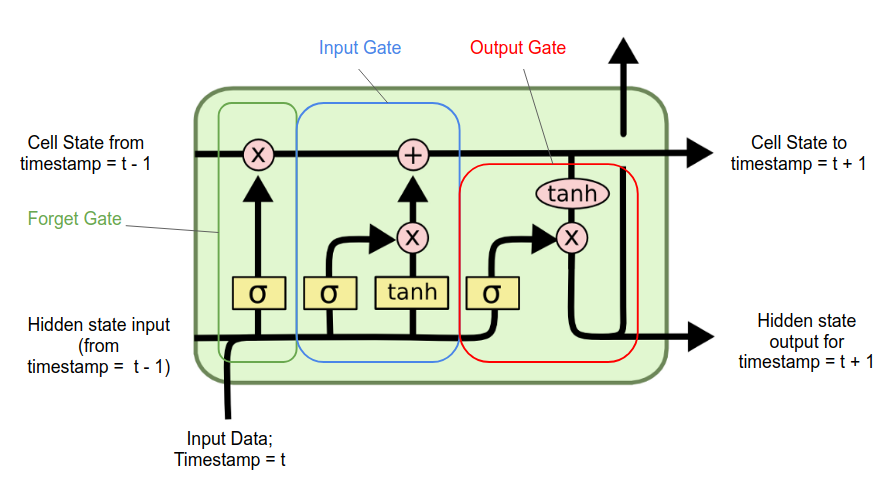

(źródło: https://medium.com/analytics-vidhya/lstms-explained-a-complete-technically-accurate-conceptual-guide-with-keras-2a650327e8f2)

## Zadanie 3 – Prognozowanie szeregu czasowego z użyciem LSTM

Celem zadania jest zbudowanie modelu prognozowania szeregu czasowego dla zbioru **AirPassengers** z wykorzystaniem komórki **LSTM**.

Model LSTM należy wytrenować w sposób analogiczny do modelu **RNN**, który został zbudowany w poprzednim zadaniu. W najprostszym wariancie można uzyskać taki model poprzez:

- zastąpienie warstwy `SimpleRNN` warstwą `LSTM`
- ewentualne dostosowanie liczby neuronów lub liczby warstw w architekturze sieci

Dokumentacja warstwy:
https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM

---

### Kroki do wykonania

1. Zbudować model sieci neuronowej wykorzystujący warstwę **LSTM**.
2. Wytrenować model na tym samym zbiorze treningowym co model **SimpleRNN**.
3. Wykonać predykcję dla danych testowych.
4. Obliczyć metryki jakości predykcji:
   - **MSE (Mean Squared Error)**
   - **MAE (Mean Absolute Error)**
5. Porównać wyniki z modelem wykorzystującym **SimpleRNN**.

---

### Analiza wyników

Porównanie modeli powinno obejmować:

- wartości metryk **MSE** i **MAE** na zbiorze testowym
- **wizualizację predykcji** obu modeli na wspólnym wykresie wraz z rzeczywistymi wartościami szeregu czasowego

Pozwoli to ocenić, czy zastosowanie komórki **LSTM**, która lepiej modeluje zależności długoterminowe, prowadzi do poprawy jakości prognozy.

---

**NOTE**

Aby porównanie modeli było rzetelne, należy zastosować **identyczne przetwarzanie danych** jak w przypadku modelu SimpleRNN, w szczególności:

- ten sam sposób **skalowania danych**
- tę samą długość sekwencji wejściowej (*sequence length*)
- ten sam podział na **zbiór treningowy i testowy**

## Zadanie 4 – Agregacja szeregu czasowego (EXTRA)

Dane w szeregach czasowych mogą być analizowane na różnych poziomach **agregacji czasowej** (np. dzień, miesiąc, kwartał, rok). Zmiana poziomu agregacji wpływa na:

- liczbę dostępnych obserwacji,
- poziom szumu w danych,
- widoczność trendów i sezonowości,
- sposób przygotowania danych dla modeli uczenia maszynowego.

Agregacja może również wpływać na **proces trenowania modeli sieci neuronowych**, ponieważ zmienia się długość szeregu oraz charakter zależności czasowych.

W zbiorze **AirPassengers** dane są zapisane w **agregacji miesięcznej**. W tym zadaniu należy przekształcić je do **agregacji rocznej**.

---

### Zadanie

1. Wykonać **roczną agregację** danych ze zbioru **AirPassengers**.
2. Wartości w każdym roku powinny zostać **uśrednione**.
3. Zwizualizować otrzymany zagregowany szereg czasowy na wykresie.

---

### Wskazówki

Do wykonania agregacji można wykorzystać funkcje biblioteki **pandas**.

W szczególności:

- w razie potrzeby przekonwertować kolumnę z datą na typ `datetime` przy użyciu funkcji `to_datetime`
- ustawić kolumnę dat jako **indeks czasowy**
- użyć metody `resample`, aby zmienić częstotliwość szeregu czasowego

Dokumentacja:

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html

Podczas agregacji można użyć parametru:

- `rule='Y'` lub `rule='YE'` – agregacja roczna

---

**TIP**

Po agregacji liczba punktów danych będzie znacznie mniejsza niż w przypadku danych miesięcznych. Warto zwrócić uwagę, jak wpływa to na **kształt szeregu czasowego** oraz widoczność trendu w danych.

## Zadanie 5 – Modelowanie szeregu czasowego COVID-19 z użyciem RNN

Celem zadania jest zbudowanie modeli prognozujących liczbę **potwierdzonych przypadków COVID-19** na podstawie danych historycznych. Dane mają charakter **szeregu czasowego**, dlatego zastosowane zostaną modele rekurencyjne (**RNN / LSTM**), które potrafią wykorzystywać zależności pomiędzy kolejnymi obserwacjami w czasie.

W zadaniu porównane zostaną dwa typy architektur:

- **SimpleRNN** – podstawowa komórka rekurencyjna
- **LSTM** – bardziej zaawansowana komórka umożliwiająca modelowanie długoterminowych zależności

W obu przypadkach wykorzystany zostanie model **many-to-one**, w którym kilka kolejnych obserwacji szeregu czasowego stanowi wejście modelu, a wyjściem jest **jedna prognozowana wartość**.

Do oceny jakości predykcji należy wykorzystać metryki:

- **MAE (Mean Absolute Error)**
- **MSE (Mean Squared Error)**

---

## 5.1. Model SimpleRNN – dane dzienne

Wytrenować model prognozowania liczby przypadków COVID-19 z wykorzystaniem warstwy **`SimpleRNN`**.

**Założenia:**

- dane wejściowe: **agregacja dzienna**
- dane nie powinny być dodatkowo modyfikowane (poza standardowym przygotowaniem do modelu)

**Kroki:**

1. Zbudować i wytrenować model **many-to-one** z warstwą `SimpleRNN`.
2. Obliczyć metryki **MAE** oraz **MSE** na zbiorze testowym.
3. Zwizualizować:
   - rzeczywiste wartości szeregu czasowego
   - predykcje modelu na danych testowych.

---

## 5.2. Model LSTM – dane dzienne

Powtórzyć eksperyment z wykorzystaniem modelu **LSTM**.

**Kroki:**

1. Zbudować model **many-to-one** z warstwą `LSTM`.
2. Wytrenować model na tych samych danych treningowych.
3. Obliczyć metryki **MAE** oraz **MSE** na zbiorze testowym.
4. Zwizualizować:
   - rzeczywiste wartości danych testowych
   - predykcje modelu.

---

## 5.3. Porównanie modeli

Porównać modele:

- **SimpleRNN (many-to-one)**
- **LSTM (many-to-one)**

Porównanie powinno obejmować:

- wartości metryk **MAE** i **MSE** na zbiorze testowym
- wizualne porównanie **predykcji na wykresie**

Na tej podstawie należy ocenić, czy zastosowanie komórki **LSTM** poprawia jakość prognozy.


In [ ]:
# Load dataset
data_covid = pd.read_csv("https://raw.githubusercontent.com/datasets/covid-19/main/data/time-series-19-covid-combined.csv")
data_covid['Date'] = pd.to_datetime(data_covid['Date'])
data_covid = data_covid.groupby('Date')['Confirmed'].sum().reset_index()
data_covid.index = data_covid.Date
data_covid.drop("Date", axis=1, inplace=True)

In [ ]:
data_covid.head()

---

## Zadanie 5.4. Model LSTM – dane z agregacją tygodniową (EXTRA)

W ostatnim kroku należy sprawdzić, jak **zmiana poziomu agregacji danych** wpływa na działanie modelu.

**Kroki:**

1. Utworzyć nowy zbiór danych z **agregacją tygodniową**:
   - agregacja może być wykonana poprzez **średnią** lub **medianę**.
2. Przygotować dane do modelowania:
   - przeskalować dane (jeśli było stosowane wcześniej)
   - wybrać odpowiednią długość sekwencji wejściowej (**`seq_length`**).
3. Wytrenować model **LSTM many-to-one** na danych tygodniowych.
4. Obliczyć metryki **MAE** i **MSE** dla zbioru testowego.
5. Wykonać **prognozę dla 5 kolejnych punktów czasowych** po danych testowych.
6. Zwizualizować:
   - dane rzeczywiste
   - predykcje modelu
   - prognozę przyszłych wartości.

## Zadanie 6 – Wpływ skalowania zmiennej wyjściowej na jakość modelu

Celem zadania jest sprawdzenie, czy **skalowanie danych wyjściowych (targetu)** wpływa na skuteczność modeli **RNN** i **LSTM** dla zbioru danych COVID-19.

**Kroki do wykonania:**

1. Zastosować skalowanie zmiennej wyjściowej `Confirmed` dla zbioru danych Covid przy użyciu **`MinMaxScaler`** z biblioteki `scikit-learn`.
2. Wytrenować modele:
   - **SimpleRNN (many-to-one)**
   - **LSTM (many-to-one)**
3. Wykonać predykcje dla danych testowych.
4. Odwrócić skalowanie predykcji przy użyciu metody `inverse_transform`, aby porównać je z oryginalnymi wartościami.
5. Porównać metryki **MAE** i **MSE** z wynikami modeli wytrenowanych ze skalowaniem targetu i bez skalowania.

**NOTE:** Skalowanie targetu może poprawić stabilność i skuteczność uczenia sieci neuronowej, ale **wszystkie predykcje muszą być przekształcone z powrotem** do oryginalnej skali przed interpretacją wyników.



---

## Zadanie 7 – Modelowanie liczby zgonów w COVID-19

W tym zadaniu wykonamy analogiczną analizę jak w **Zadaniu 5**, ale dla zmiennej `Deaths`.

**Kroki do wykonania:**

1. Przygotować dane dzienne dotyczące liczby zgonów (`Deaths`).
2. Zbudować i wytrenować modele:
   - **SimpleRNN (many-to-one)**
   - **LSTM (many-to-one)**
3. Obliczyć metryki **MAE** i **MSE** dla danych testowych.
4. Wykonać prognozę dla 5 przyszłych punktów czasowych i zwizualizować je na wykresie.

---

In [ ]:
# Load dataset
data_covid = pd.read_csv("https://raw.githubusercontent.com/datasets/covid-19/main/data/time-series-19-covid-combined.csv")
data_covid['Date'] = pd.to_datetime(data_covid['Date'])
data_covid = data_covid.groupby('Date')['Deaths'].sum().reset_index()
data_covid.index = data_covid.Date
data_covid.drop("Date", axis=1, inplace=True)